# Predicción de rotación de empleados con scikit-learn

## 1. Preparación para el modelado

El objetivo es construir un modelo de clasificación binaria que estime la probabilidad de rotación de un empleado.

La variable objetivo es:

- `0`: el empleado permaneció.
- `1`: el empleado abandonó la empresa.

Los datos se dividirán en conjuntos de entrenamiento y prueba antes de realizar cualquier transformación, con el propósito de prevenir fuga de información.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

ruta = "/content/employee_attrition_limpio.csv"

df_modelo = pd.read_csv(ruta)

print("Dimensiones:", df_modelo.shape)

df_modelo.head()

Dimensiones: (1470, 31)


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,1,Travel_Rarely,1102,Sales,1,2,Life Sciences,2,Female,...,3,1,0,8,0,1,6,4,0,5
1,49,0,Travel_Frequently,279,Research & Development,8,1,Life Sciences,3,Male,...,4,4,1,10,3,3,10,7,1,7
2,37,1,Travel_Rarely,1373,Research & Development,2,2,Other,4,Male,...,3,2,0,7,3,3,0,0,0,0
3,33,0,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,4,Female,...,3,3,0,8,3,3,8,7,3,0
4,27,0,Travel_Rarely,591,Research & Development,2,1,Medical,1,Male,...,3,4,1,6,3,3,2,2,2,2


## 2. Separación de variables predictoras y variable objetivo

- `X` contendrá las características utilizadas para realizar la predicción.
- `y` contendrá el resultado que queremos predecir: la rotación.

In [2]:
X = df_modelo.drop(
    columns="Attrition"
)

y = df_modelo["Attrition"]

print("Dimensiones de X:", X.shape)
print("Dimensiones de y:", y.shape)
print()
print("Distribución de la variable objetivo:")
print(y.value_counts())

Dimensiones de X: (1470, 30)
Dimensiones de y: (1470,)

Distribución de la variable objetivo:
Attrition
0    1233
1     237
Name: count, dtype: int64


## 3. División en entrenamiento y prueba

Se utilizará el 80% de los registros para entrenar el modelo y el 20% para realizar la evaluación final.

La división será estratificada para conservar aproximadamente la misma proporción de rotación en ambos conjuntos.

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (1176, 30)
X_test: (294, 30)
y_train: (1176,)
y_test: (294,)


In [4]:
print("Distribución en entrenamiento:")
print(y_train.value_counts())
print()
print("Porcentajes en entrenamiento:")
print(y_train.value_counts(normalize=True).mul(100).round(2))
print()
print("Distribución en prueba:")
print(y_test.value_counts())
print()
print("Porcentajes en prueba:")
print(y_test.value_counts(normalize=True).mul(100).round(2))

Distribución en entrenamiento:
Attrition
0    986
1    190
Name: count, dtype: int64

Porcentajes en entrenamiento:
Attrition
0    83.84
1    16.16
Name: proportion, dtype: float64

Distribución en prueba:
Attrition
0    247
1     47
Name: count, dtype: int64

Porcentajes en prueba:
Attrition
0    84.01
1    15.99
Name: proportion, dtype: float64


## 4. Identificación de variables numéricas y categóricas

Las variables numéricas y categóricas necesitan tratamientos diferentes:

- Las numéricas serán estandarizadas.
- Las categóricas serán transformadas mediante codificación one-hot.
- Aunque actualmente no existen valores faltantes, se agregarán mecanismos de imputación para que el pipeline sea más robusto.

In [5]:
variables_numericas = (
    X_train
    .select_dtypes(include="number")
    .columns
    .tolist()
)

variables_categoricas = (
    X_train
    .select_dtypes(exclude="number")
    .columns
    .tolist()
)

print(
    "Número de variables numéricas:",
    len(variables_numericas)
)

print(
    "Número de variables categóricas:",
    len(variables_categoricas)
)

print("\nVariables categóricas:")

for variable in variables_categoricas:
    print("-", variable)

Número de variables numéricas: 23
Número de variables categóricas: 7

Variables categóricas:
- BusinessTravel
- Department
- EducationField
- Gender
- JobRole
- MaritalStatus
- OverTime


In [7]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

In [8]:
pipeline_numerico = Pipeline(
    steps=[
        (
            "imputacion",
            SimpleImputer(strategy="median")
        ),
        (
            "escalado",
            StandardScaler()
        )
    ]
)

In [9]:
pipeline_categorico = Pipeline(
    steps=[
        (
            "imputacion",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)

In [10]:
preprocesador = ColumnTransformer(
    transformers=[
        (
            "numericas",
            pipeline_numerico,
            variables_numericas
        ),
        (
            "categoricas",
            pipeline_categorico,
            variables_categoricas
        )
    ]
)

preprocesador

ColumnTransformer(transformers=[('numericas',
                                 Pipeline(steps=[('imputacion',
                                                  SimpleImputer(strategy='median')),
                                                 ('escalado',
                                                  StandardScaler())]),
                                 ['Age', 'DailyRate', 'DistanceFromHome',
                                  'Education', 'EnvironmentSatisfaction',
                                  'HourlyRate', 'JobInvolvement', 'JobLevel',
                                  'JobSatisfaction', 'MonthlyIncome',
                                  'MonthlyRate', 'NumCompaniesWorked',
                                  'PercentSalaryHike', 'Pe...
                                  'TrainingTimesLastYear', 'WorkLifeBalance',
                                  'YearsAtCompany', 'YearsInCurrentRole',
                                  'YearsSinceLastPromotion',
                                  'YearsWithCurrManager']),
                                ('categoricas',
                                 Pipeline(steps=[('imputacion',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehot',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['BusinessTravel', 'Department',
                                  'EducationField', 'Gender', 'JobRole',
                                  'MaritalStatus', 'OverTime'])])

## 5. Modelo base

Se utilizará un clasificador ingenuo que siempre predice la clase mayoritaria. Su resultado servirá como punto de comparación para evaluar si el modelo de machine learning aporta valor real.

In [11]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)

modelo_base = DummyClassifier(
    strategy="most_frequent"
)

modelo_base.fit(
    X_train,
    y_train
)

predicciones_base = modelo_base.predict(
    X_test
)

print(
    "Accuracy del modelo base:",
    round(
        accuracy_score(
            y_test,
            predicciones_base
        ),
        4
    )
)

print("\nMatriz de confusión:")

print(
    confusion_matrix(
        y_test,
        predicciones_base
    )
)

Accuracy del modelo base: 0.8401

Matriz de confusión:
[[247   0]
 [ 47   0]]


## 6. Regresión logística con clases balanceadas

La regresión logística será el primer modelo real. Se utilizará `class_weight="balanced"` para dar mayor importancia a la clase minoritaria durante el entrenamiento.

In [12]:
from sklearn.linear_model import LogisticRegression

modelo_logistico = Pipeline(
    steps=[
        (
            "preprocesador",
            preprocesador
        ),
        (
            "modelo",
            LogisticRegression(
                max_iter=1000,
                class_weight="balanced",
                random_state=42
            )
        )
    ]
)

modelo_logistico.fit(
    X_train,
    y_train
)

Pipeline(steps=[('preprocesador',
                 ColumnTransformer(transformers=[('numericas',
                                                  Pipeline(steps=[('imputacion',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('escalado',
                                                                   StandardScaler())]),
                                                  ['Age', 'DailyRate',
                                                   'DistanceFromHome',
                                                   'Education',
                                                   'EnvironmentSatisfaction',
                                                   'HourlyRate',
                                                   'JobInvolvement', 'JobLevel',
                                                   'JobSatisfaction',
                                                   'MonthlyIncome',
                                                   'MonthlyRate',
                                                   'NumCompani...
                                                   'YearsSinceLastPromotion',
                                                   'YearsWithCurrManager']),
                                                 ('categoricas',
                                                  Pipeline(steps=[('imputacion',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['BusinessTravel',
                                                   'Department',
                                                   'EducationField', 'Gender',
                                                   'JobRole', 'MaritalStatus',
                                                   'OverTime'])])),
                ('modelo',
                 LogisticRegression(class_weight='balanced', max_iter=1000,
                                    random_state=42))])

In [13]:
predicciones_logisticas = modelo_logistico.predict(
    X_test
)

probabilidades_logisticas = (
    modelo_logistico
    .predict_proba(X_test)[:, 1]
)

print(
    "Primeras 10 predicciones:",
    predicciones_logisticas[:10]
)

print(
    "Primeras 10 probabilidades:",
    probabilidades_logisticas[:10].round(3)
)

Primeras 10 predicciones: [0 0 0 0 1 1 0 0 0 0]
Primeras 10 probabilidades: [0.287 0.022 0.408 0.04  0.674 0.642 0.081 0.15  0.021 0.238]


In [14]:
print("Reporte de clasificación:\n")

print(
    classification_report(
        y_test,
        predicciones_logisticas,
        digits=3,
        zero_division=0
    )
)

auc_logistico = roc_auc_score(
    y_test,
    probabilidades_logisticas
)

print(
    "ROC-AUC:",
    round(auc_logistico, 3)
)

print("\nMatriz de confusión:")

print(
    confusion_matrix(
        y_test,
        predicciones_logisticas
    )
)

Reporte de clasificación:

              precision    recall  f1-score   support

           0      0.918     0.773     0.840       247
           1      0.349     0.638     0.451        47

    accuracy                          0.752       294
   macro avg      0.634     0.706     0.645       294
weighted avg      0.827     0.752     0.777       294

ROC-AUC: 0.803

Matriz de confusión:
[[191  56]
 [ 17  30]]


## 7. Evaluación visual del modelo

Se visualizarán los aciertos y errores de la regresión logística mediante una matriz de confusión.

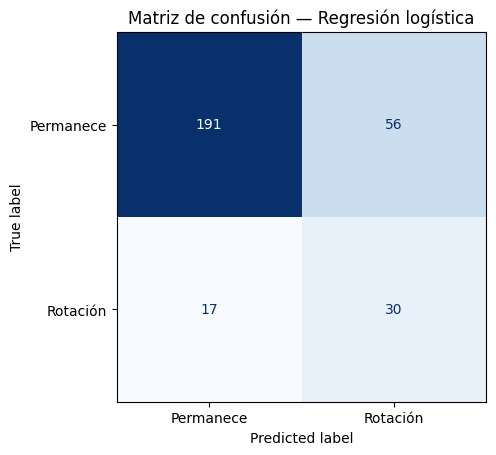

In [15]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    predicciones_logisticas,
    display_labels=[
        "Permanece",
        "Rotación"
    ],
    cmap="Blues",
    colorbar=False
)

plt.title(
    "Matriz de confusión — Regresión logística"
)

plt.show()

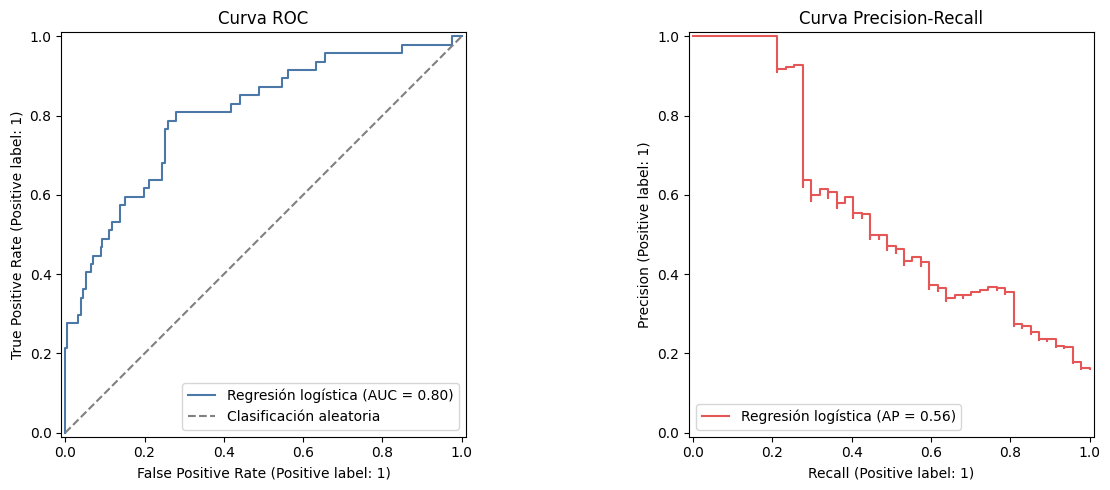

Average Precision: 0.561


In [16]:
from sklearn.metrics import (
    RocCurveDisplay,
    PrecisionRecallDisplay,
    average_precision_score
)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(13, 5)
)

RocCurveDisplay.from_predictions(
    y_test,
    probabilidades_logisticas,
    name="Regresión logística",
    color="#4C78A8",
    ax=axes[0]
)

axes[0].plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    color="gray",
    label="Clasificación aleatoria"
)

axes[0].set_title("Curva ROC")
axes[0].legend()

PrecisionRecallDisplay.from_predictions(
    y_test,
    probabilidades_logisticas,
    name="Regresión logística",
    color="#E45756",
    ax=axes[1]
)

axes[1].set_title("Curva Precision-Recall")

plt.tight_layout()
plt.show()

average_precision = average_precision_score(
    y_test,
    probabilidades_logisticas
)

print(
    "Average Precision:",
    round(average_precision, 3)
)

## 8. Selección del umbral de decisión

El umbral predeterminado es 0.50. Reducirlo permite detectar más casos de rotación, pero también genera más falsas alertas.

El umbral se analizará mediante validación cruzada usando exclusivamente el conjunto de entrenamiento.

In [17]:
from sklearn.model_selection import (
    StratifiedKFold,
    cross_val_predict
)

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score
)

validacion_cruzada = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

probabilidades_cv = cross_val_predict(
    modelo_logistico,
    X_train,
    y_train,
    cv=validacion_cruzada,
    method="predict_proba",
    n_jobs=-1
)[:, 1]

print(
    "Probabilidades generadas:",
    len(probabilidades_cv)
)

Probabilidades generadas: 1176


In [18]:
resultados_umbrales = []

for umbral in [0.30, 0.40, 0.50, 0.60, 0.70]:

    predicciones_umbral = (
        probabilidades_cv >= umbral
    ).astype(int)

    resultados_umbrales.append({
        "Umbral": umbral,
        "Precision": precision_score(
            y_train,
            predicciones_umbral,
            zero_division=0
        ),
        "Recall": recall_score(
            y_train,
            predicciones_umbral,
            zero_division=0
        ),
        "F1": f1_score(
            y_train,
            predicciones_umbral,
            zero_division=0
        )
    })

tabla_umbrales = pd.DataFrame(
    resultados_umbrales
).round(3)

tabla_umbrales

,Umbral,Precision,Recall,F1
0,0.3,0.289,0.847,0.431
1,0.4,0.321,0.795,0.458
2,0.5,0.368,0.737,0.491
3,0.6,0.452,0.668,0.539
4,0.7,0.552,0.584,0.568


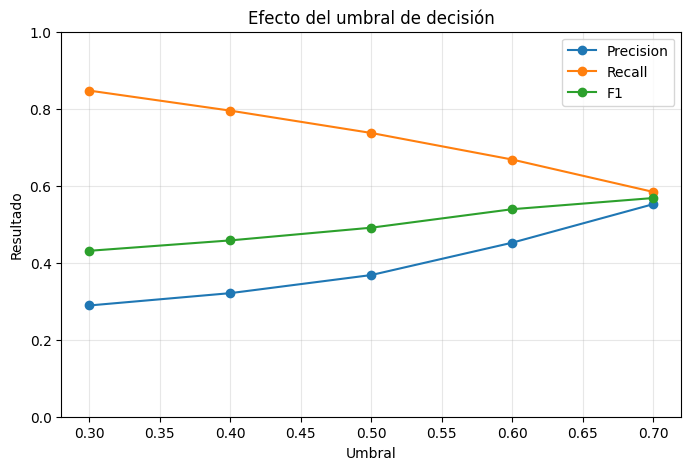

In [19]:
plt.figure(figsize=(8, 5))

plt.plot(
    tabla_umbrales["Umbral"],
    tabla_umbrales["Precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    tabla_umbrales["Umbral"],
    tabla_umbrales["Recall"],
    marker="o",
    label="Recall"
)

plt.plot(
    tabla_umbrales["Umbral"],
    tabla_umbrales["F1"],
    marker="o",
    label="F1"
)

plt.title("Efecto del umbral de decisión")
plt.xlabel("Umbral")
plt.ylabel("Resultado")
plt.ylim(0, 1)
plt.grid(alpha=0.3)
plt.legend()
plt.show()

In [20]:
umbral_negocio = 0.40

predicciones_umbral_040 = (
    probabilidades_logisticas >= umbral_negocio
).astype(int)

print(
    classification_report(
        y_test,
        predicciones_umbral_040,
        digits=3,
        zero_division=0
    )
)

print(
    confusion_matrix(
        y_test,
        predicciones_umbral_040
    )
)

              precision    recall  f1-score   support

           0      0.947     0.721     0.818       247
           1      0.349     0.787     0.484        47

    accuracy                          0.731       294
   macro avg      0.648     0.754     0.651       294
weighted avg      0.851     0.731     0.765       294

[[178  69]
 [ 10  37]]


## 9. Comparación de modelos

Se comparará la regresión logística con Random Forest mediante validación cruzada estratificada. La comparación utilizará exclusivamente el conjunto de entrenamiento.

In [21]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.base import clone

modelo_random_forest = Pipeline(
    steps=[
        (
            "preprocesador",
            clone(preprocesador)
        ),
        (
            "modelo",
            RandomForestClassifier(
                n_estimators=500,
                max_depth=8,
                min_samples_leaf=5,
                class_weight="balanced",
                random_state=42,
                n_jobs=1
            )
        )
    ]
)

modelo_random_forest

Pipeline(steps=[('preprocesador',
                 ColumnTransformer(transformers=[('numericas',
                                                  Pipeline(steps=[('imputacion',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('escalado',
                                                                   StandardScaler())]),
                                                  ['Age', 'DailyRate',
                                                   'DistanceFromHome',
                                                   'Education',
                                                   'EnvironmentSatisfaction',
                                                   'HourlyRate',
                                                   'JobInvolvement', 'JobLevel',
                                                   'JobSatisfaction',
                                                   'MonthlyIncome',
                                                   'MonthlyRate',
                                                   'NumCompani...
                                                  Pipeline(steps=[('imputacion',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['BusinessTravel',
                                                   'Department',
                                                   'EducationField', 'Gender',
                                                   'JobRole', 'MaritalStatus',
                                                   'OverTime'])])),
                ('modelo',
                 RandomForestClassifier(class_weight='balanced', max_depth=8,
                                        min_samples_leaf=5, n_estimators=500,
                                        n_jobs=1, random_state=42))])

In [22]:
from sklearn.model_selection import cross_validate

modelos = {
    "Regresión logística": modelo_logistico,
    "Random Forest": modelo_random_forest
}

metricas = [
    "roc_auc",
    "average_precision",
    "precision",
    "recall",
    "f1"
]

resultados_modelos = []

for nombre, modelo in modelos.items():

    resultados_cv = cross_validate(
        modelo,
        X_train,
        y_train,
        cv=validacion_cruzada,
        scoring=metricas,
        n_jobs=-1
    )

    resultados_modelos.append({
        "Modelo": nombre,
        "ROC-AUC": resultados_cv[
            "test_roc_auc"
        ].mean(),
        "Average Precision": resultados_cv[
            "test_average_precision"
        ].mean(),
        "Precision": resultados_cv[
            "test_precision"
        ].mean(),
        "Recall": resultados_cv[
            "test_recall"
        ].mean(),
        "F1": resultados_cv[
            "test_f1"
        ].mean()
    })

comparacion_modelos = pd.DataFrame(
    resultados_modelos
).set_index("Modelo").round(3)

comparacion_modelos

,ROC-AUC,Average Precision,Precision,Recall,F1
Modelo,,,,,
Regresión logística,0.827,0.606,0.372,0.737,0.492
Random Forest,0.805,0.562,0.608,0.411,0.479


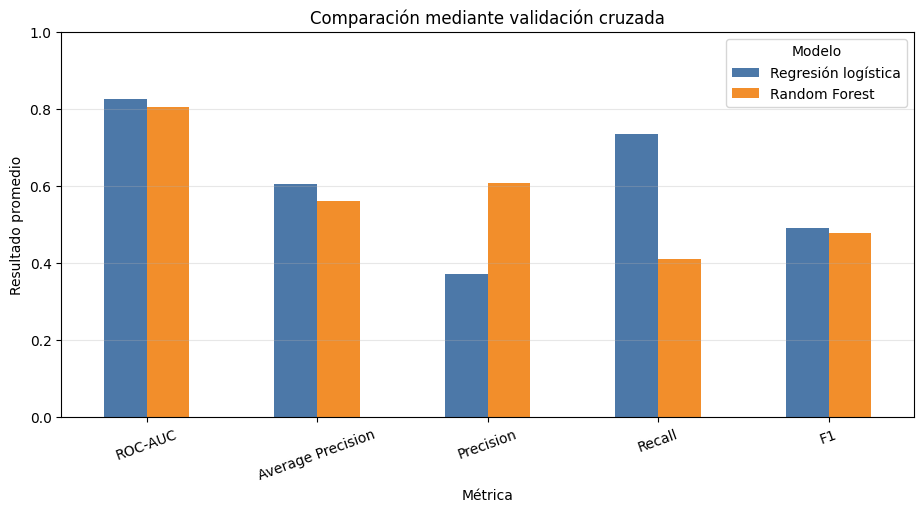

In [23]:
comparacion_grafica = comparacion_modelos[
    [
        "ROC-AUC",
        "Average Precision",
        "Precision",
        "Recall",
        "F1"
    ]
].transpose()

comparacion_grafica.plot(
    kind="bar",
    figsize=(11, 5),
    color=[
        "#4C78A8",
        "#F28E2B"
    ]
)

plt.title(
    "Comparación mediante validación cruzada"
)

plt.xlabel("Métrica")
plt.ylabel("Resultado promedio")
plt.xticks(rotation=20)
plt.ylim(0, 1)
plt.legend(title="Modelo")
plt.grid(
    axis="y",
    alpha=0.3
)
plt.show()

In [24]:
pipeline_categorico_denso = Pipeline(
    steps=[
        (
            "imputacion",
            SimpleImputer(
                strategy="most_frequent"
            )
        ),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            )
        )
    ]
)

preprocesador_denso = ColumnTransformer(
    transformers=[
        (
            "numericas",
            clone(pipeline_numerico),
            variables_numericas
        ),
        (
            "categoricas",
            pipeline_categorico_denso,
            variables_categoricas
        )
    ]
)

## 10. Modelo HistGradientBoosting

Este modelo construye árboles de forma secuencial. Cada nuevo árbol intenta corregir parte de los errores cometidos por los árboles anteriores.

In [25]:
from sklearn.ensemble import (
    HistGradientBoostingClassifier
)

modelo_boosting = Pipeline(
    steps=[
        (
            "preprocesador",
            preprocesador_denso
        ),
        (
            "modelo",
            HistGradientBoostingClassifier(
                max_iter=200,
                learning_rate=0.05,
                max_leaf_nodes=15,
                min_samples_leaf=20,
                l2_regularization=1.0,
                class_weight="balanced",
                random_state=42
            )
        )
    ]
)

modelo_boosting

Pipeline(steps=[('preprocesador',
                 ColumnTransformer(transformers=[('numericas',
                                                  Pipeline(steps=[('imputacion',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('escalado',
                                                                   StandardScaler())]),
                                                  ['Age', 'DailyRate',
                                                   'DistanceFromHome',
                                                   'Education',
                                                   'EnvironmentSatisfaction',
                                                   'HourlyRate',
                                                   'JobInvolvement', 'JobLevel',
                                                   'JobSatisfaction',
                                                   'MonthlyIncome',
                                                   'MonthlyRate',
                                                   'NumCompani...
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['BusinessTravel',
                                                   'Department',
                                                   'EducationField', 'Gender',
                                                   'JobRole', 'MaritalStatus',
                                                   'OverTime'])])),
                ('modelo',
                 HistGradientBoostingClassifier(class_weight='balanced',
                                                l2_regularization=1.0,
                                                learning_rate=0.05,
                                                max_iter=200, max_leaf_nodes=15,
                                                random_state=42))])

In [26]:
modelos = {
    "Regresión logística": modelo_logistico,
    "Random Forest": modelo_random_forest,
    "HistGradientBoosting": modelo_boosting
}

resultados_modelos = []

for nombre, modelo in modelos.items():

    resultados_cv = cross_validate(
        modelo,
        X_train,
        y_train,
        cv=validacion_cruzada,
        scoring=metricas,
        n_jobs=-1
    )

    resultados_modelos.append({
        "Modelo": nombre,
        "ROC-AUC": resultados_cv[
            "test_roc_auc"
        ].mean(),
        "Average Precision": resultados_cv[
            "test_average_precision"
        ].mean(),
        "Precision": resultados_cv[
            "test_precision"
        ].mean(),
        "Recall": resultados_cv[
            "test_recall"
        ].mean(),
        "F1": resultados_cv[
            "test_f1"
        ].mean()
    })

comparacion_modelos = pd.DataFrame(
    resultados_modelos
).set_index("Modelo").round(3)

comparacion_modelos

,ROC-AUC,Average Precision,Precision,Recall,F1
Modelo,,,,,
Regresión logística,0.827,0.606,0.372,0.737,0.492
Random Forest,0.805,0.562,0.608,0.411,0.479
HistGradientBoosting,0.810,0.571,0.569,0.479,0.518


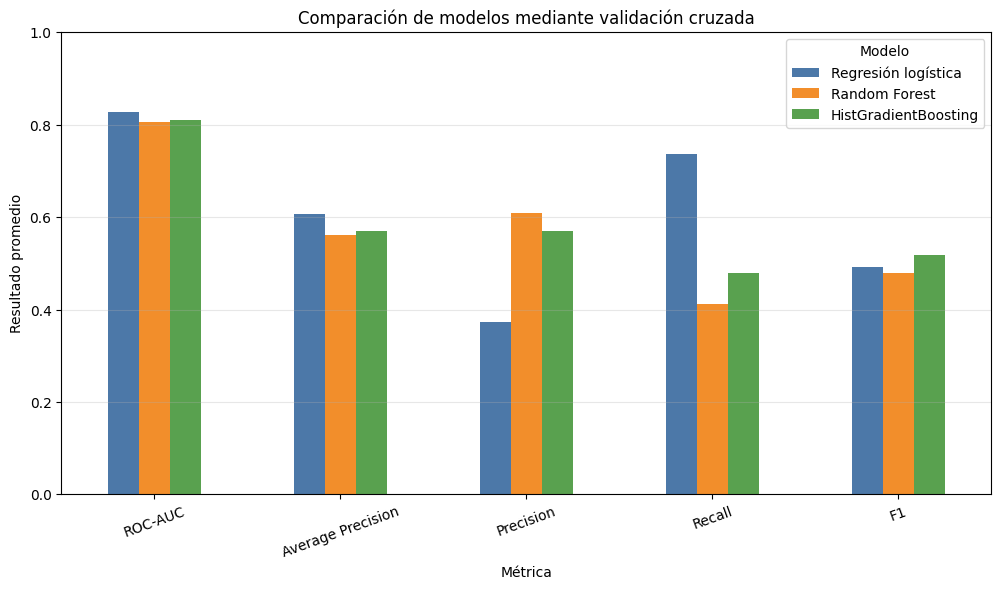

In [27]:
comparacion_grafica = comparacion_modelos.transpose()

comparacion_grafica.plot(
    kind="bar",
    figsize=(12, 6),
    color=[
        "#4C78A8",
        "#F28E2B",
        "#59A14F"
    ]
)

plt.title(
    "Comparación de modelos mediante validación cruzada"
)

plt.xlabel("Métrica")
plt.ylabel("Resultado promedio")
plt.xticks(rotation=20)
plt.ylim(0, 1)
plt.legend(title="Modelo")
plt.grid(
    axis="y",
    alpha=0.3
)

plt.show()

## 11. Interpretación del modelo

Se utilizará importancia por permutación para medir cuánto contribuye cada variable original a la capacidad predictiva de la regresión logística.

La importancia indica cuánto disminuye el ROC-AUC cuando los valores de una variable se mezclan aleatoriamente.

In [28]:
from sklearn.inspection import permutation_importance

resultado_importancia = permutation_importance(
    modelo_logistico,
    X_test,
    y_test,
    scoring="roc_auc",
    n_repeats=30,
    random_state=42,
    n_jobs=-1
)

importancia_variables = pd.DataFrame({
    "Variable": X_test.columns,
    "Importancia media":
        resultado_importancia.importances_mean,
    "Desviación":
        resultado_importancia.importances_std
})

importancia_variables = (
    importancia_variables
    .sort_values(
        "Importancia media",
        ascending=False
    )
    .reset_index(drop=True)
)

importancia_variables.head(15).round(4)

,Variable,Importancia media,Desviación
0,OverTime,0.1054,0.0118
1,NumCompaniesWorked,0.0263,0.0098
2,MaritalStatus,0.0238,0.0092
3,YearsSinceLastPromotion,0.0234,0.0083
4,BusinessTravel,0.0204,0.0087
5,JobSatisfaction,0.0200,0.0092
6,TrainingTimesLastYear,0.0144,0.0045
7,JobRole,0.0129,0.0137
8,JobInvolvement,0.0122,0.0079
9,EnvironmentSatisfaction,0.0120,0.0101


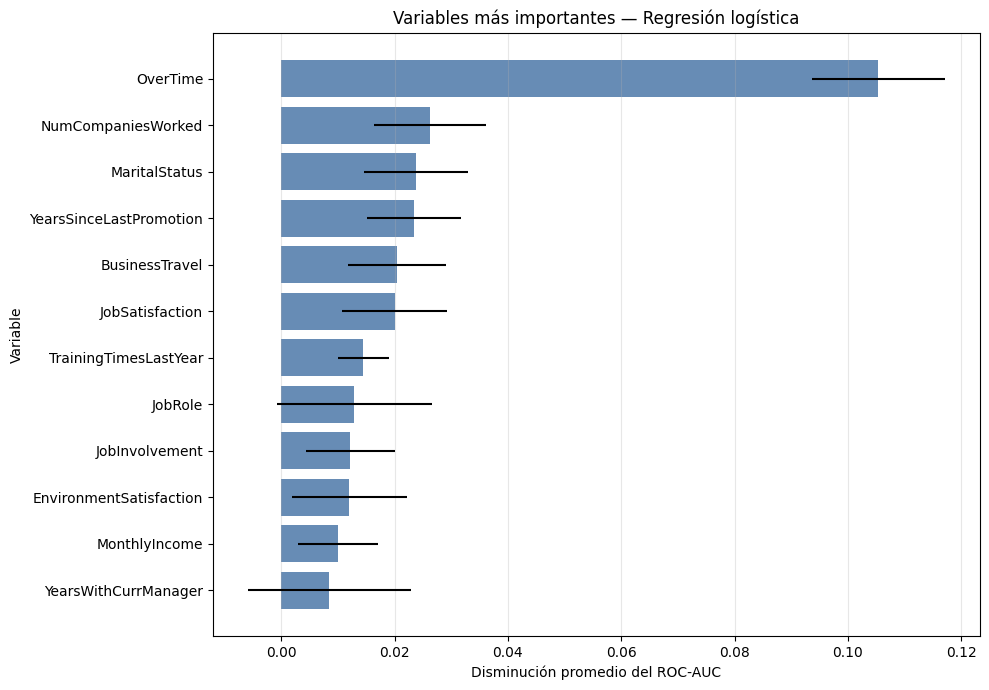

In [29]:
top_variables = (
    importancia_variables
    .head(12)
    .sort_values("Importancia media")
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_variables["Variable"],
    top_variables["Importancia media"],
    xerr=top_variables["Desviación"],
    color="#4C78A8",
    alpha=0.85
)

plt.title(
    "Variables más importantes — Regresión logística"
)

plt.xlabel(
    "Disminución promedio del ROC-AUC"
)

plt.ylabel("Variable")
plt.grid(
    axis="x",
    alpha=0.3
)

plt.tight_layout()
plt.show()

## 12. Evaluación sin variables sensibles

Se construirá una segunda regresión logística excluyendo edad, género y estado civil. El objetivo es comprobar si estas características son necesarias para mantener el desempeño predictivo.

Las variables sensibles se conservarán únicamente para futuras auditorías de equidad, pero no se utilizarán como entradas del modelo.

In [30]:
variables_sensibles = [
    "Age",
    "Gender",
    "MaritalStatus"
]

X_train_responsable = X_train.drop(
    columns=variables_sensibles
)

X_test_responsable = X_test.drop(
    columns=variables_sensibles
)

print(
    "Variables del modelo original:",
    X_train.shape[1]
)

print(
    "Variables sin datos sensibles:",
    X_train_responsable.shape[1]
)

Variables del modelo original: 30
Variables sin datos sensibles: 27


In [31]:
numericas_responsables = (
    X_train_responsable
    .select_dtypes(include="number")
    .columns
    .tolist()
)

categoricas_responsables = (
    X_train_responsable
    .select_dtypes(exclude="number")
    .columns
    .tolist()
)

preprocesador_responsable = ColumnTransformer(
    transformers=[
        (
            "numericas",
            clone(pipeline_numerico),
            numericas_responsables
        ),
        (
            "categoricas",
            clone(pipeline_categorico),
            categoricas_responsables
        )
    ]
)

modelo_responsable = Pipeline(
    steps=[
        (
            "preprocesador",
            preprocesador_responsable
        ),
        (
            "modelo",
            LogisticRegression(
                max_iter=1000,
                class_weight="balanced",
                random_state=42
            )
        )
    ]
)

modelo_responsable

Pipeline(steps=[('preprocesador',
                 ColumnTransformer(transformers=[('numericas',
                                                  Pipeline(steps=[('imputacion',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('escalado',
                                                                   StandardScaler())]),
                                                  ['DailyRate',
                                                   'DistanceFromHome',
                                                   'Education',
                                                   'EnvironmentSatisfaction',
                                                   'HourlyRate',
                                                   'JobInvolvement', 'JobLevel',
                                                   'JobSatisfaction',
                                                   'MonthlyIncome',
                                                   'MonthlyRate',
                                                   'NumCompaniesWork...
                                                   'YearsInCurrentRole',
                                                   'YearsSinceLastPromotion',
                                                   'YearsWithCurrManager']),
                                                 ('categoricas',
                                                  Pipeline(steps=[('imputacion',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['BusinessTravel',
                                                   'Department',
                                                   'EducationField', 'JobRole',
                                                   'OverTime'])])),
                ('modelo',
                 LogisticRegression(class_weight='balanced', max_iter=1000,
                                    random_state=42))])

In [32]:
resultados_cv_responsable = cross_validate(
    modelo_responsable,
    X_train_responsable,
    y_train,
    cv=validacion_cruzada,
    scoring=metricas,
    n_jobs=-1
)

resultado_responsable = {
    "ROC-AUC": resultados_cv_responsable[
        "test_roc_auc"
    ].mean(),
    "Average Precision":
        resultados_cv_responsable[
            "test_average_precision"
        ].mean(),
    "Precision": resultados_cv_responsable[
        "test_precision"
    ].mean(),
    "Recall": resultados_cv_responsable[
        "test_recall"
    ].mean(),
    "F1": resultados_cv_responsable[
        "test_f1"
    ].mean()
}

comparacion_etica = pd.DataFrame(
    [
        comparacion_modelos
        .loc["Regresión logística"]
        .to_dict(),
        resultado_responsable
    ],
    index=[
        "Con variables sensibles",
        "Sin variables sensibles"
    ]
).round(3)

comparacion_etica

,ROC-AUC,Average Precision,Precision,Recall,F1
Con variables sensibles,0.827,0.606,0.372,0.737,0.492
Sin variables sensibles,0.827,0.593,0.374,0.737,0.495


In [33]:
modelo_responsable.fit(
    X_train_responsable,
    y_train
)

predicciones_responsables = (
    modelo_responsable
    .predict(X_test_responsable)
)

probabilidades_responsables = (
    modelo_responsable
    .predict_proba(
        X_test_responsable
    )[:, 1]
)

print(
    classification_report(
        y_test,
        predicciones_responsables,
        digits=3,
        zero_division=0
    )
)

print(
    "ROC-AUC:",
    round(
        roc_auc_score(
            y_test,
            probabilidades_responsables
        ),
        3
    )
)

print(
    "Average Precision:",
    round(
        average_precision_score(
            y_test,
            probabilidades_responsables
        ),
        3
    )
)

print("\nMatriz de confusión:")

print(
    confusion_matrix(
        y_test,
        predicciones_responsables
    )
)

              precision    recall  f1-score   support

           0      0.920     0.789     0.850       247
           1      0.366     0.638     0.465        47

    accuracy                          0.765       294
   macro avg      0.643     0.714     0.657       294
weighted avg      0.831     0.765     0.788       294

ROC-AUC: 0.78
Average Precision: 0.543

Matriz de confusión:
[[195  52]
 [ 17  30]]


In [34]:
resultados_cv_responsable = cross_validate(
    modelo_responsable,
    X_train_responsable,
    y_train,
    cv=validacion_cruzada,
    scoring=metricas,
    n_jobs=-1
)

resultado_responsable = pd.Series({
    "ROC-AUC": resultados_cv_responsable[
        "test_roc_auc"
    ].mean(),
    "Average Precision":
        resultados_cv_responsable[
            "test_average_precision"
        ].mean(),
    "Precision": resultados_cv_responsable[
        "test_precision"
    ].mean(),
    "Recall": resultados_cv_responsable[
        "test_recall"
    ].mean(),
    "F1": resultados_cv_responsable[
        "test_f1"
    ].mean()
})

comparacion_etica = pd.DataFrame({
    "Con variables sensibles":
        comparacion_modelos.loc[
            "Regresión logística"
        ],
    "Sin variables sensibles":
        resultado_responsable
}).transpose().round(3)

comparacion_etica

,ROC-AUC,Average Precision,Precision,Recall,F1
Con variables sensibles,0.827,0.606,0.372,0.737,0.492
Sin variables sensibles,0.827,0.593,0.374,0.737,0.495


In [35]:
modelo_responsable.fit(
    X_train_responsable,
    y_train
)

predicciones_responsables = (
    modelo_responsable
    .predict(X_test_responsable)
)

probabilidades_responsables = (
    modelo_responsable
    .predict_proba(
        X_test_responsable
    )[:, 1]
)

print(
    classification_report(
        y_test,
        predicciones_responsables,
        digits=3,
        zero_division=0
    )
)

print(
    "ROC-AUC:",
    round(
        roc_auc_score(
            y_test,
            probabilidades_responsables
        ),
        3
    )
)

print(
    "Average Precision:",
    round(
        average_precision_score(
            y_test,
            probabilidades_responsables
        ),
        3
    )
)

print(
    "\nMatriz de confusión:"
)

print(
    confusion_matrix(
        y_test,
        predicciones_responsables
    )
)

              precision    recall  f1-score   support

           0      0.920     0.789     0.850       247
           1      0.366     0.638     0.465        47

    accuracy                          0.765       294
   macro avg      0.643     0.714     0.657       294
weighted avg      0.831     0.765     0.788       294

ROC-AUC: 0.78
Average Precision: 0.543

Matriz de confusión:
[[195  52]
 [ 17  30]]


## 13. Selección del umbral final

Se compararán dos escenarios:

- Umbral 0.50: escenario equilibrado.
- Umbral 0.40: escenario de mayor sensibilidad, orientado a detectar más rotaciones.

In [36]:
resultados_umbral_final = []

for umbral in [0.40, 0.50]:

    predicciones_temporales = (
        probabilidades_responsables >= umbral
    ).astype(int)

    matriz = confusion_matrix(
        y_test,
        predicciones_temporales
    )

    tn, fp, fn, tp = matriz.ravel()

    resultados_umbral_final.append({
        "Umbral": umbral,
        "Precision": precision_score(
            y_test,
            predicciones_temporales,
            zero_division=0
        ),
        "Recall": recall_score(
            y_test,
            predicciones_temporales,
            zero_division=0
        ),
        "F1": f1_score(
            y_test,
            predicciones_temporales,
            zero_division=0
        ),
        "Rotaciones detectadas": tp,
        "Alertas falsas": fp,
        "Rotaciones no detectadas": fn
    })

comparacion_umbral_final = pd.DataFrame(
    resultados_umbral_final
).round(3)

comparacion_umbral_final

,Umbral,Precision,Recall,F1,Rotaciones detectadas,Alertas falsas,Rotaciones no detectadas
0,0.4,0.303,0.702,0.423,33,76,14
1,0.5,0.366,0.638,0.465,30,52,17


## 14. Predicciones para visualización

Para el dashboard se generarán predicciones mediante validación cruzada. Cada empleado será evaluado por un modelo que no utilizó ese registro durante su entrenamiento.

Las variables sensibles podrán conservarse únicamente para análisis y auditoría, pero no serán entregadas al modelo como variables predictoras.

In [37]:
X_responsable = X.drop(
    columns=variables_sensibles
)

probabilidades_oof = cross_val_predict(
    modelo_responsable,
    X_responsable,
    y,
    cv=validacion_cruzada,
    method="predict_proba",
    n_jobs=-1
)[:, 1]

umbral_final = 0.50

predicciones_oof = (
    probabilidades_oof >= umbral_final
).astype(int)

print(
    "Predicciones generadas:",
    len(predicciones_oof)
)

Predicciones generadas: 1470


In [38]:
resultados_dashboard = (
    X.reset_index(drop=True).copy()
)

resultados_dashboard.insert(
    0,
    "RegistroAnonimo",
    np.arange(
        1,
        len(resultados_dashboard) + 1
    )
)

resultados_dashboard["RotacionReal"] = np.where(
    y.to_numpy() == 1,
    "Sí",
    "No"
)

resultados_dashboard["PuntajeRiesgo"] = (
    probabilidades_oof
)

resultados_dashboard["AlertaModelo"] = np.where(
    predicciones_oof == 1,
    "Sí",
    "No"
)

resultados_dashboard["NivelRiesgo"] = pd.cut(
    resultados_dashboard["PuntajeRiesgo"],
    bins=[
        -np.inf,
        0.30,
        0.50,
        np.inf
    ],
    labels=[
        "Bajo",
        "Medio",
        "Alto"
    ],
    right=False
)

resultados_dashboard["AciertoModelo"] = np.where(
    predicciones_oof == y.to_numpy(),
    "Sí",
    "No"
)

resultados_dashboard[
    [
        "RegistroAnonimo",
        "RotacionReal",
        "PuntajeRiesgo",
        "NivelRiesgo",
        "AlertaModelo",
        "AciertoModelo"
    ]
].head(10)

,RegistroAnonimo,RotacionReal,PuntajeRiesgo,NivelRiesgo,AlertaModelo,AciertoModelo
0,1,Sí,0.894774,Alto,Sí,Sí
1,2,No,0.137319,Bajo,No,Sí
2,3,Sí,0.796595,Alto,Sí,Sí
3,4,No,0.610348,Alto,Sí,No
4,5,No,0.577847,Alto,Sí,No
5,6,No,0.216887,Bajo,No,Sí
6,7,No,0.488195,Medio,No,Sí
7,8,No,0.294226,Bajo,No,Sí
8,9,No,0.251523,Bajo,No,Sí
9,10,No,0.140309,Bajo,No,Sí


In [39]:
ruta_dashboard = (
    "/content/resultados_dashboard_rotacion.csv"
)

resultados_dashboard.to_csv(
    ruta_dashboard,
    index=False
)

print(
    "Archivo guardado:",
    ruta_dashboard
)

print(
    "Dimensiones:",
    resultados_dashboard.shape
)

Archivo guardado: /content/resultados_dashboard_rotacion.csv
Dimensiones: (1470, 36)


In [40]:
from google.colab import files

files.download(ruta_dashboard)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [41]:
import joblib

modelo_final = clone(
    modelo_responsable
)

modelo_final.fit(
    X_responsable,
    y
)

artefacto_modelo = {
    "modelo": modelo_final,
    "umbral": umbral_final,
    "columnas_esperadas":
        X_responsable.columns.tolist(),
    "variables_excluidas":
        variables_sensibles,
    "significado_clases": {
        0: "Permanece",
        1: "Rotación"
    }
}

ruta_modelo = (
    "/content/modelo_rotacion_final.joblib"
)

joblib.dump(
    artefacto_modelo,
    ruta_modelo
)

print(
    "Modelo guardado:",
    ruta_modelo
)

Modelo guardado: /content/modelo_rotacion_final.joblib


In [42]:
files.download(ruta_modelo)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>